In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import cv2
import matplotlib.pyplot as plt


(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print(f"Training data shape: {x_train.shape}")

Training data shape: (60000, 28, 28)


In [23]:
autoencoder = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dense(16, activation="relu"),

    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(784, activation="sigmoid"),
    layers.Reshape((28, 28))
])

autoencoder.compile(optimizer='adam', loss='mae')
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,464 (415.88 KB)

 Trainable params: 106,464 (415.88 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = autoencoder.fit(
    x_train, x_train,
    epochs=50,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2146 - val_loss: 0.1201
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1161 - val_loss: 0.1098
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1071 - val_loss: 0.1030
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1019 - val_loss: 0.0988
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0977 - val_loss: 0.0957
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0944 - val_loss: 0.0926
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0917 - val_loss: 0.0900
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0891 - val_loss: 0.0874
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0866 - val_loss: 0.0860
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0850 - val_loss: 0.0835
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0828 - val_loss: 0.0820
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [25]:
img_path = 'mal3.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))
img = img.astype('float32') / 255.0

img = 1.0 - img

my_character = np.expand_dims(img, axis=0)

print("Character processed and ready.")

Character processed and ready.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step


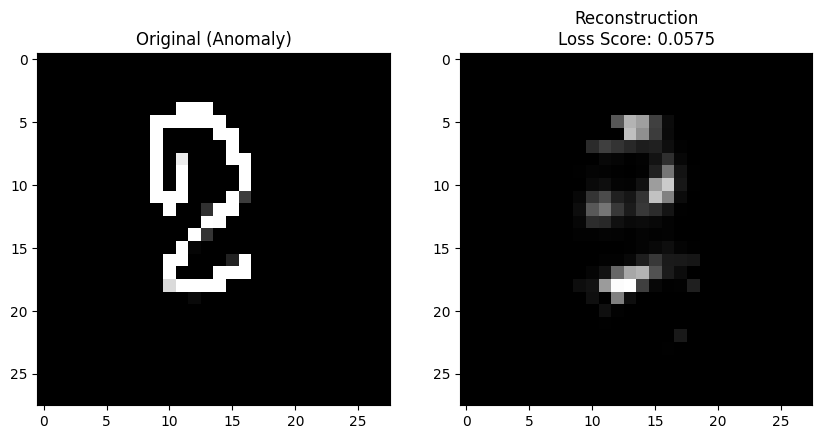

Result: Anomaly Detected!


In [26]:
reconstruction = autoencoder.predict(my_character)

error = np.mean(np.abs(my_character - reconstruction))


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original (Anomaly)")
plt.imshow(my_character[0], cmap='gray')

plt.subplot(1, 2, 2)
plt.title(f"Reconstruction\nLoss Score: {error:.4f}")
plt.imshow(reconstruction[0], cmap='gray')

plt.show()

if error > 0.05:
    print("Result: Anomaly Detected!")
else:
    print("Result: Normal Data")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step


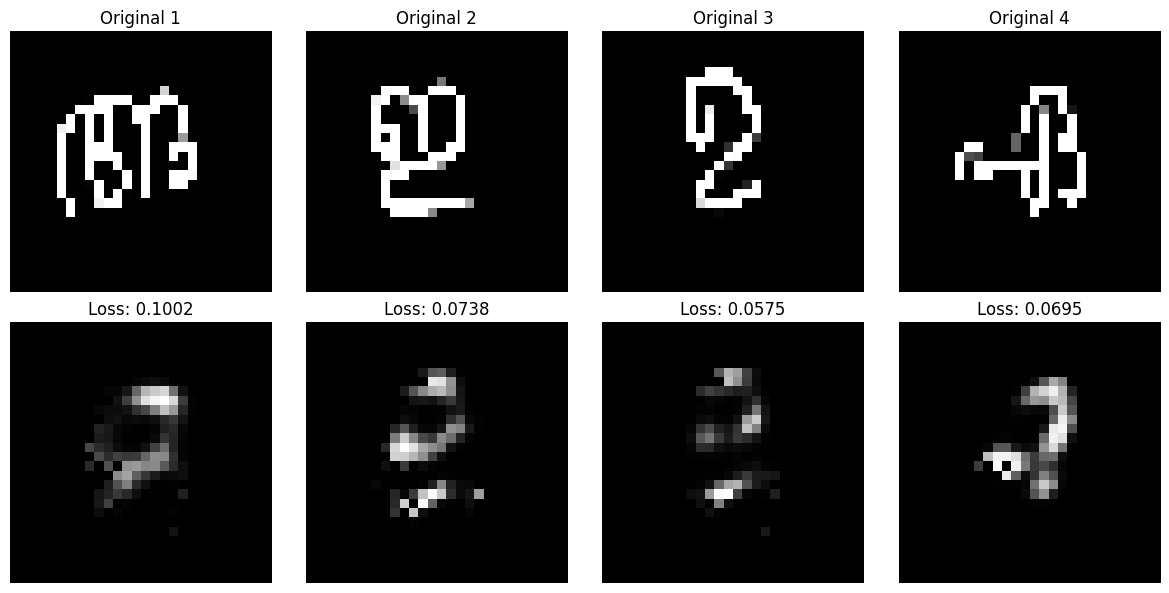

Individual Losses: [0.1001663  0.07379816 0.05754554 0.06954203]
Batch Average Anomaly Loss: 0.0753


In [27]:
filenames = ['mal1.png', 'mal2.png', 'mal3.png', 'mal.png']
mal_images = []

for file in filenames:
    img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28, 28))
    img = img.astype('float32') / 255.0
    img = 1.0 - img
    mal_images.append(img)

mal_batch = np.array(mal_images)

reconstructions_mal = autoencoder.predict(mal_batch)

flat_mal = mal_batch.reshape(-1, 784)
flat_recon = reconstructions_mal.reshape(-1, 784)

individual_losses = np.mean(np.abs(flat_recon - flat_mal), axis=1)

plt.figure(figsize=(12, 6))
for i in range(len(filenames)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(mal_batch[i], cmap='gray')
    plt.title(f"Original {i+1}")
    plt.axis('off')

    plt.subplot(2, 4, i + 5)
    plt.imshow(reconstructions_mal[i], cmap='gray')
    plt.title(f"Loss: {individual_losses[i]:.4f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Individual Losses: {individual_losses}")
print(f"Batch Average Anomaly Loss: {np.mean(individual_losses):.4f}")

- **From the above, what I understood is, the 3rd character which is having similarity to 3, has less loss value and others are having more loss value. Meaning as loss increase anomaly is present.**
- **Complex images like the first one has higher anomaly**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


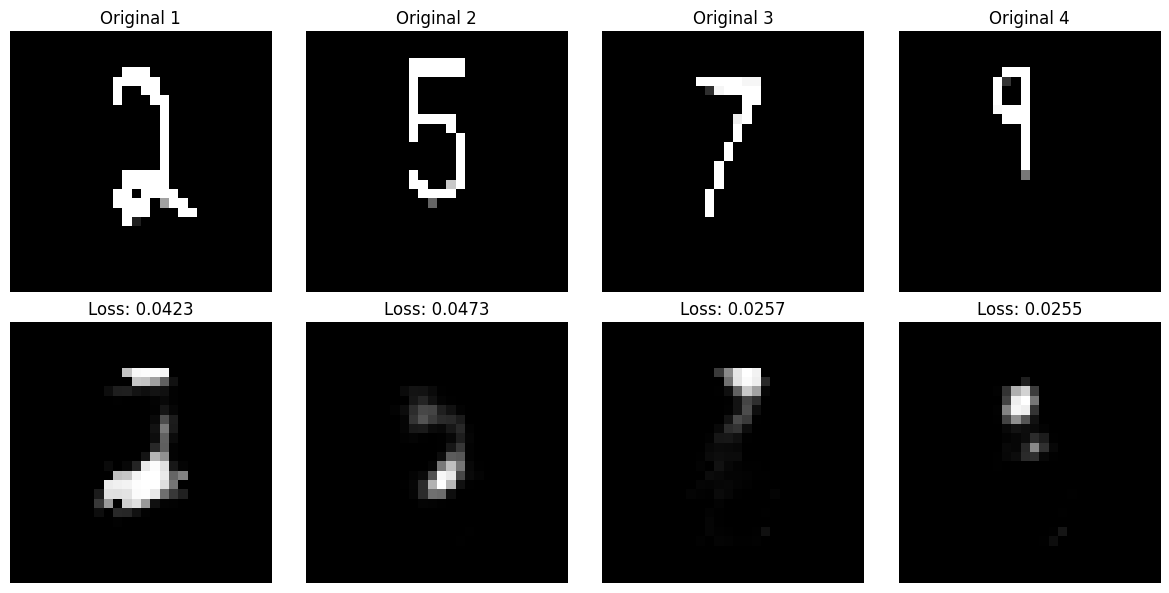

Individual Losses: [0.04226919 0.04725647 0.0257404  0.02547257]
Batch Average Anomaly Loss: 0.0352


In [28]:


filenames = ['num2.png', 'num5.png', 'num7.png', 'num9.png']
mal_images = []

for file in filenames:
    img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28, 28))
    img = img.astype('float32') / 255.0
    img = 1.0 - img
    mal_images.append(img)

mal_batch = np.array(mal_images)

reconstructions_mal = autoencoder.predict(mal_batch)

flat_mal = mal_batch.reshape(-1, 784)
flat_recon = reconstructions_mal.reshape(-1, 784)

individual_losses = np.mean(np.abs(flat_recon - flat_mal), axis=1)

plt.figure(figsize=(12, 6))
for i in range(len(filenames)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(mal_batch[i], cmap='gray')
    plt.title(f"Original {i+1}")
    plt.axis('off')

    plt.subplot(2, 4, i + 5)
    plt.imshow(reconstructions_mal[i], cmap='gray')
    plt.title(f"Loss: {individual_losses[i]:.4f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Individual Losses: {individual_losses}")
print(f"Batch Average Anomaly Loss: {np.mean(individual_losses):.4f}")

- **Just to confirm what I said above, I reconstructed the numbers itself, itwas giving lower errors compared to the malayalam letters. More complex numbers like 5 was giving high loss.**